# CIS I — Assignment 1: Pivot Calibration

This notebook walks through the pivot-calibration scenario from the
assignment handout (Figure 1): a pointer and a calibration object, each
carrying a marker body, observed by an optical tracker. Your job is to
**design** the marker-sphere layouts and workspace placements, then
**calibrate** the pointer's tip position `p_tip` to within about 2mm.

Everything runs against `src.simulation`, a self-contained simulator (no
server, no network calls) that plays the role of the physical tracker +
hand-guided robot + calibration sensor described in the handout. It injects
realistic, hidden measurement noise — your code never sees ground truth
except where explicitly noted for **validation/reporting** in Step 8 (real
hardware wouldn't give you that; the point there is to report your achieved
accuracy, not to use the ground truth in your calibration math itself).

Sections below are numbered to match the handout's "The Problem" steps 1-8.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
from src import simulation
from src import vct3, Rot, Frame

np.set_printoptions(precision=3, suppress=True)


In [2]:
# Seeded for a reproducible worked example -- delete/change this if you want
# to see run-to-run variance (this is a stochastic simulation; your report
# should reflect that a single run's numbers aren't the whole story).
np.random.seed(10)


## Step 1: Design the pointer's marker body

Choose approximate local marker-sphere positions `a_ptr,k` (a `List[vct3]`,
relative to the pointer's own coordinate frame) and the pointer tip's
approximate local position `p_tip_approx` (a `vct3`). These are your
*nominal design values* — the simulator will independently perturb the
*actual* manufactured positions by a small, hidden amount (bounded at
2mm per the handout), which is exactly why later steps calibrate rather
than trust these numbers directly.

Design considerations (put your reasoning in your report):
- At least 4 markers, **not coplanar** (a planar layout can't fully
  constrain 3-D orientation).
- Spread the markers out — a wider layout is *less* sensitive to a fixed
  amount of per-marker manufacturing/sensor noise when the tracker solves
  for this body's orientation (a small marker-position error translates to
  a larger *angular* error on a tightly clustered layout than a spread-out
  one).
- Keep the whole body physically plausible for a hand-held pointer (tens of
  mm, not meters), and remember the tip is likely tens of cm from the
  marker cluster.


In [3]:
# 7 markers, spread across a ~90mm layout, deliberately non-coplanar
ptr_local_positions = [
    vct3(0, 0, 0),
    vct3(90, 0, 0),
    vct3(-40, 80, 0),
    vct3(0, 0, 90),
    vct3(60, 60, 50),
    vct3(-50, 30, 70),
    vct3(30, -60, 40),
]
ptr_tip_approx = vct3(0, 0, -150)  # tip 150mm "below" the marker cluster


## Step 1 (continued): Design the calibration object's marker body

Same idea, for the calibration object's local marker positions `a_cal,k`.


In [4]:
# Wider spread than the pointer (the calibration object doesn't need to be
# hand-held) -- a wider layout is markedly less sensitive to a fixed amount
# of per-marker manufacturing/sensor noise (see Step 1's markdown).
cal_local_positions = [
    vct3(0, 0, 0),
    vct3(180, 0, 0),
    vct3(0, 180, 0),
    vct3(0, 0, 180),
    vct3(90, 90, 90),
    vct3(180, 180, 0),
]


## Step 2: Approximate workspace poses

Specify approximate poses (as `Frame`s) for the tracking camera
(`F_tracker`) and the calibration object (`F_cal`), relative to the
workspace. The tracker's usable volume is the tetrahedral region in the
handout's Figure 2 (roughly 100-200cm in front of the tracker, widening
from ~120cm to ~200cm across) — place the calibration object, and later
the pointer, so they're comfortably inside that volume.


In [5]:
# Tracker at the workspace origin, looking down +x; calibration object well
# inside its tetrahedral volume, off to one side of the {100..500mm} test cube.
F_tracker_approx = Frame(Rot(), vct3(0, 0, 0))
F_cal_approx = Frame(Rot(), vct3(500, 0, 0))


## Step 3: Build the simulated rig

Fully provided — this just wires up your Step 1/2 design choices through
`simulation`'s `DefineMarkerBody` / `PlaceMarkerBody` / `CreateTracker`
equivalents. `ptr_placed`/`cal_placed` are `PlacedBody` handles: each pairs
a `MarkerBody` with its hidden actual placement, and gets passed to
`simulation.sample_marker_bodies(...)` whenever you want a reading.


In [6]:
ptr_mb = simulation.define_marker_body("ptr_mb", ptr_local_positions)
cal_mb = simulation.define_marker_body("cal_mb", cal_local_positions)

cal_placed = simulation.place_marker_body(cal_mb, F_cal_approx)
# The pointer's own body doesn't have a meaningful "workspace placement" yet
# -- it moves every time it's hand-guided (Step 4-6). precision="precise"
# matches a robot-controlled pose rather than a coarsely, manually placed
# static object (see place_marker_body's docstring).
ptr_placed = simulation.place_marker_body(ptr_mb, Frame.eye(), precision="precise")

ptr = simulation.define_pointer("ptr1", ptr_tip_approx, ptr_mb)
trk = simulation.create_tracker("trk1", F_tracker_approx)

print("rig built:", ptr_mb.name, cal_mb.name, ptr.name, trk.name)


rig built: ptr_mb cal_mb ptr1 trk1


## Step 3 (continued): Refine `a_ptr,k` / `a_cal,k`

> "Observations of marker positions can be used to determine accurate
> estimates of relative positions a_ptr,k of markers on pointer and
> calibration objects... **Hint**: You probably want to take multiple
> readings in order to reduce the uncertainty associated with the a_k
> values."

While a marker body sits still, each `simulation.sample_marker_bodies`
reading independently registers its *currently assumed* nominal geometry
against a noisy observation and returns a best-fit `Frame`. Transforming
each reading's observed marker positions back into the body's own local
frame with the *inverse* of that fit, then averaging across many readings,
converges your nominal estimate toward the true (hidden) geometry — the
random per-reading tracker/sensor noise averages out, leaving a much
smaller residual than a single reading would.


In [7]:
def refine_marker_body(trk, placed, n_readings=30, passes=3):
    """
    Refines placed.body's nominal marker positions toward the (hidden) true
    manufactured geometry by repeated registration + averaging.

    input:
        trk - Tracker to read with
        placed - PlacedBody whose body's nominal marker positions should be
            refined in place (via body.set_marker_positions(...))
        n_readings - int, readings to average per pass
        passes - int, how many times to repeat (registering against the
            just-updated nominal each time tightens the estimate further)
    output: None (mutates placed.body's nominal_marker_positions in place)
    """
    body = placed.body
    for _ in range(passes):
        accum = [[] for _ in body.nominal_marker_positions]
        for _ in range(n_readings):
            obs = simulation.sample_marker_bodies(trk, [placed])
            F_inv = obs[body.name].frame.inv()
            for k, marker in enumerate(obs[body.name].markers):
                accum[k].append((F_inv * marker.p).vec.ravel())
        refined = [vct3(*np.mean(pts, axis=0)) for pts in accum]
        body.set_marker_positions(refined)


refine_marker_body(trk, ptr_placed)
refine_marker_body(trk, cal_placed)
print("refined nominal marker positions for ptr_mb and cal_mb")


refined nominal marker positions for ptr_mb and cal_mb


## Steps 4-6: Collect pivot-calibration observations

For each observation `j`: hand-guide the pointer near the calibration
object at some desired orientation `R_desired,j`, take one simultaneous
tracker reading of *both* bodies, and read the calibration sensor. Loop
skeleton is provided; you choose how many observations to take and how to
vary `R_desired,j` (variety in orientation matters for what Step 7 needs to
solve for — a pointer that's barely rotated between readings gives an
ill-conditioned system).


In [8]:
N_OBSERVATIONS = 50

F_ptr_list = []
F_cal_list = []
sensed_tip_list = []
rng = np.random.default_rng(10)
for j in range(N_OBSERVATIONS):
    # a random axis + a moderate, non-trivial angle each time -- avoids the
    # ill-conditioning a narrow orientation range would cause in Step 7
    axis = rng.normal(size=3)
    axis /= np.linalg.norm(axis)
    angle = rng.uniform(0.3, 1.2)
    R_desired = Rot(axis, angle=angle)

    hg = simulation.hand_guide_pointer(ptr, ptr_placed, cal_placed, R_desired)
    obs = simulation.sample_marker_bodies(trk, [ptr_placed, cal_placed])
    sensed = simulation.sense_tip(ptr, hg)

    F_ptr_list.append(obs["ptr_mb"].frame)
    F_cal_list.append(obs["cal_mb"].frame)
    sensed_tip_list.append(sensed)

n_in_range = sum(s is not None for s in sensed_tip_list)
print(f"collected {len(F_ptr_list)} observations, {n_in_range} within calibration-sensor range")


collected 50 observations, 49 within calibration-sensor range


`sensed_tip_list` holds each observation's high-accuracy calibration-sensor
reading (or `None` if that observation ended up outside the sensor's 5mm
range) — useful as an independent sanity check on your calibration later,
since it measures the tip position a completely different way (directly,
rather than through the pointer's marker geometry).


## Step 7: Compute a calibrated value for `p_tip`

This is the assignment's core deliverable — implement it yourself rather
than reusing a library pivot-calibration function.

**Derivation sketch** (work through the details in your report): while the
tip stays at one fixed physical point across all `N` observations, each
observation's pointer pose satisfies `R_j @ p_tip + p_j = p_dimple` for
some fixed but unknown `p_dimple` (the pivot point's position in whatever
frame `R_j, p_j` are expressed in) — a linear system in the unknowns
`p_tip` and `p_dimple` once you stack all `N` observations, solvable by
least squares.

**Corner case to consider**: `F_ptr_list` alone (each observation's pointer
pose *relative to the tracker*) includes the tracker's own pose jiggling
between readings (see the handout's tracker-pose noise, sigma_Tp) — is that
small enough to ignore, or does your system need to use `F_cal_list` too
(the calibration object was read *simultaneously*, from the same tracker
pose, every observation)?

**Minimum data**: how many observations, and what about their rotations,
are needed for the stacked system to actually be solvable (well-
conditioned, not rank-deficient)?


In [9]:
def compute_pivot_calibration(F_ptr_list, F_cal_list):
    """
    Standard least-squares pivot calibration.

    Expresses each observation's pointer pose RELATIVE TO the simultaneously-
    observed calibration object (F_rel,j = Fcal,j^-1 * Fptr,j) rather than
    using F_ptr_list directly: both were read from the same tracker pose at
    that instant, so the tracker's own pose jiggle (sigma_Tp) cancels out of
    the relative pose, leaving only the much smaller marker/sensor noise.

    While the tip stays at one fixed physical point p_dimple across all N
    observations: R_j @ p_tip + p_j = p_dimple. Stacking all N observations
    gives a linear system in [p_tip; p_dimple], solved by least squares:

        [ R_j | -I_3 ] [p_tip; p_dimple] = -p_j   for j = 1..N

    input:
        F_ptr_list - List[Frame], the pointer marker body's pose relative to
            the tracker for each observation j (Fptr,j)
        F_cal_list - List[Frame], the calibration object's pose relative to
            the tracker for each observation j (Fcal,j), same order/length
    output:
        p_tip - vct3, the calibrated tip position in the pointer's local frame
        cov_estimate - np.ndarray (3x3), estimated covariance for p_tip, from
            the least-squares residuals (standard Gauss-Markov OLS covariance)
    """
    if len(F_ptr_list) != len(F_cal_list) or len(F_ptr_list) < 3:
        raise ValueError("compute_pivot_calibration requires >= 3 paired observations")

    rows, rhs = [], []
    for F_ptr, F_cal in zip(F_ptr_list, F_cal_list):
        F_rel = F_cal.inv() * F_ptr
        R = F_rel.R.matrix
        p = F_rel.p.vec.ravel()
        row = np.zeros((3, 6))
        row[:, :3] = R
        row[:, 3:] = -np.eye(3)
        rows.append(row)
        rhs.append(-p)

    A = np.vstack(rows)
    b = np.concatenate(rhs)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    p_tip = vct3(*sol[:3])

    residuals = A @ sol - b
    dof = A.shape[0] - A.shape[1]
    sigma2 = float(residuals @ residuals) / dof
    cov_full = sigma2 * np.linalg.inv(A.T @ A)
    cov_estimate = cov_full[:3, :3]

    return p_tip, cov_estimate


p_tip_est, p_tip_cov = compute_pivot_calibration(F_ptr_list, F_cal_list)


In [10]:
print("calibrated p_tip:", p_tip_est)
print("estimated covariance (mm^2):\n", p_tip_cov)
print("estimated std-dev per axis (mm):", np.sqrt(np.diag(p_tip_cov)))


calibrated p_tip: vct3(x=-0.97, y=0.06, z=-151.33)
Internal Vector:
[[  -0.97 ]
 [   0.055]
 [-151.329]]
estimated covariance (mm^2):
 [[ 0.199 -0.006 -0.008]
 [-0.006  0.209  0.007]
 [-0.008  0.007  0.189]]
estimated std-dev per axis (mm): [0.446 0.457 0.435]


## Step 8: Validate against test poses

> "**Hint**: You may want to consider placing additional marker bodies
> close to (but not inside) the cube defined by the test volume. However,
> this will also depend on your design for and placement of the
> calibration object."

The nominal test-pose grid is `theta_x, theta_y, theta_z` each in
`{0, +-pi/6, +-pi/3, +-pi/2}` and `p_x, p_y, p_z` each in
`{300, 300+-100, 300+-200}` mm. For each test pose, the handout requires a
**single observation only** (no averaging).

Think about why the hint suggests an *additional*, nearby reference body:
whatever you used to validate/calibrate against needs to be observed
*simultaneously* with the pointer to share (and thus cancel) the tracker's
per-reading pose jiggle — and the further that reference is from the test
volume, the more any of *its own* residual registration error gets
amplified by the lever arm to the test pose. The calibration object may
simply be too far from the {100mm..500mm} test cube for this purpose,
depending on where you placed it in Step 2.


In [11]:
# Same wide-spread design rationale as the calibration object (Step 1).
near_local_positions = [
    vct3(0, 0, 0),
    vct3(180, 0, 0),
    vct3(0, 180, 0),
    vct3(0, 0, 180),
    vct3(90, 90, 90),
    vct3(180, 180, 0),
]
# Centered near the test-pose cube's nominal center (300, 300, 300)
F_near_approx = Frame(Rot(), vct3(300, 300, 300))

near_mb = simulation.define_marker_body("near_mb", near_local_positions)
near_placed = simulation.place_marker_body(near_mb, F_near_approx)
refine_marker_body(trk, near_placed)
print("near-test-volume reference body ready:", near_mb.name)


near-test-volume reference body ready: near_mb


Refine this new body's geometry the same way you refined the pointer's and
calibration object's (Step 3b) before using it.


Now the single-observation test loop. For each nominal test pose `F_t`:
place the pointer there (small, robot-precision placement error, same as
the real system), take one simultaneous reading of the pointer and your
Step-8 reference body, and predict the tip's position (relative to that
reference body) using your calibrated `p_tip`.

**Ground truth for reporting only**: `PlacedBody.actual_placement` and
`MarkerBody.actual_marker_positions` hold the hidden values the simulator
sampled — you have access to them here only because this notebook doesn't
gate them behind a separate eval mode (per the handout: "During debugging
you will have access to all of the ... values. These will not be available
during evaluation."). Use them *only* to compute and report your achieved
error in this section — using them anywhere in your actual calibration math
(Steps 3b/7) defeats the point of the assignment.


In [12]:
thetas = [0, np.pi / 6, -np.pi / 6, np.pi / 3, -np.pi / 3, np.pi / 2, -np.pi / 2]
offsets = [0, 100, -100, 200, -200]
# The full grid is 7^3 * 5^3 = 42,875 combinations -- evaluate a representative
# random subset rather than every combination.
all_combos = [(rx, ry, rz, tx, ty, tz)
              for rx in thetas for ry in thetas for rz in thetas
              for tx in offsets for ty in offsets for tz in offsets]
N_TEST_POSES = 50
chosen = rng.choice(len(all_combos), size=N_TEST_POSES, replace=False)
test_poses = [Frame(Rot.xyz(rx, ry, rz), vct3(300 + tx, 300 + ty, 300 + tz))
              for rx, ry, rz, tx, ty, tz in (all_combos[i] for i in chosen)]

TRUE_TIP_FOR_DISPLAY_ONLY = np.array([0.0, 0.0, -150.0])  # matches ptr_tip_approx's nominal design

test_results = []  # list of (F_t_nominal, error_mm)
for F_t_nominal in test_poses:
    test_placed = simulation.place_marker_body(ptr_mb, F_t_nominal, precision="precise")
    obs = simulation.sample_marker_bodies(trk, [test_placed, near_placed])
    F_rel = obs["near_mb"].frame.inv() * obs["ptr_mb"].frame
    p_pred = F_rel * p_tip_est

    p_true = near_placed.actual_placement.inv() * (
        test_placed.actual_placement * vct3(*TRUE_TIP_FOR_DISPLAY_ONLY)
    )
    error_mm = (p_pred - p_true).norm()
    test_results.append((F_t_nominal, error_mm))

print(f"evaluated {len(test_results)} test poses")


evaluated 50 test poses


## Achieved performance

Summarize the tip-position error across the test-pose grid against the
handout's 2mm spec.


n test poses                50
mean error (mm)             1.245
median error (mm)           1.254
max error (mm)              2.055
poses meeting 2mm spec      49 / 50 (98.0%)


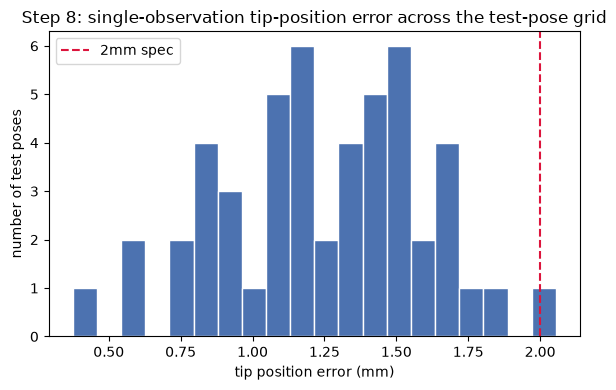

In [13]:
errors_mm = np.array([e for _, e in test_results])

print(f"{'n test poses':<28s}{len(errors_mm)}")
print(f"{'mean error (mm)':<28s}{errors_mm.mean():.3f}")
print(f"{'median error (mm)':<28s}{np.median(errors_mm):.3f}")
print(f"{'max error (mm)':<28s}{errors_mm.max():.3f}")
print(f"{'poses meeting 2mm spec':<28s}{(errors_mm <= 2.0).sum()} / {len(errors_mm)} "
      f"({100 * (errors_mm <= 2.0).mean():.1f}%)")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(errors_mm, bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(2.0, color="crimson", linestyle="--", label="2mm spec")
ax.set_xlabel("tip position error (mm)")
ax.set_ylabel("number of test poses")
ax.set_title("Step 8: single-observation tip-position error across the test-pose grid")
ax.legend()
plt.tight_layout()
plt.show()
